# 📘 Master Notebook: Optimization in Machine Learning

\

---

## 📑 Table of Contents
1. [🚀 Introduction to Optimization](#1--introduction-to-optimization)
2. [🧮 Mathematical Foundations](#2--mathematical-foundations)
3. [🤖 ML Models as Mathematical Functions](#3--ml-models-as-mathematical-functions)
4. [🎯 Loss Functions: Measuring Performance](#4--loss-functions-measuring-performance)
5. [📉 From Loss to Optimization (The "Easy Way")](#5--from-loss-to-optimization-the-easy-way)
6. [🏔️ Gradient Descent: The Engine of ML](#6--gradient-descent-the-engine-of-ml)
7. [📐 Multiple Parameters & Loss Landscapes](#7--multiple-parameters--loss-landscapes)
8. [🚧 Challenges in Optimization](#8--challenges-in-optimization)
9. [💻 Practical Implementation (Python)](#9--practical-implementation-python)
10. [🚀 Modern Optimization Algorithms](#10--modern-optimization-algorithms)
11. [🧠 The Deep Learning Bridge](#11--the-deep-learning-bridge)
12. [📝 Interview Cheat Sheet & Debugging](#12--interview-cheat-sheet--debugging)

---

## 1. 🚀 Introduction to Optimization

### Why Optimization?
Imagine you are trying to throw a ball into a basket. Initially, your throws are inaccurate. After every throw, you observe the error, adjust your aim, and throw again. Eventually, you become accurate.

Machine Learning works exactly the same way. Instead of improving your physical aim, the algorithm improves its **parameters** until predictions become accurate.

```mermaid
flowchart LR
    A[Input Data] --> B[Model]
    B --> C[Prediction]
    C --> D[Calculate Error]
    D --> E[Update Parameters]
    E --> B
    
    style A fill:#e3f2fd,stroke:#1565c0
    style E fill:#c8e6c9,stroke:#2e7d32
```


**Optimization** is simply the process of finding the set of parameters that minimizes the prediction error (Loss Function).

---

## 2. 🧮 Mathematical Foundations

Before understanding how machine learning models learn, we must first define what they fundamentally are.

### What is a Function?
A **function** is a mathematical rule that maps an input to exactly one output.

$$ y = f(x) $$

### Single vs. Multi-Variable Functions

* **Single-Variable Function**: Takes one input. Example: 

$$f(x) = x^2 + 2x$$

* **Multi-Variable Function**: Takes multiple inputs to produce an output. Real-world ML models rely on this because outcomes depend on multiple features.Examples: 

$$z = f(x_1, x_2, \dots, x_n)$$

Predicting house price based on area, bedrooms, and location: $Price = f(Area, Beds, Location)$.

### Variables vs. Parameters
Students often confuse these two concepts. They are **not** the same. For example, in $y = mx + b$, $x$ is the variable, while $m$ and $b$ are the parameters that the model must learn.

| Concept | Definition | Role in ML | Analogy (Coffee Machine) |
| :--- | :--- | :--- | :--- |
| **Variable** | The input data provided to the function. | Changes for every observation (rows in dataset). | The coffee beans and water you put in. |
| **Parameter** | Constants/coefficients that define the function's behavior. | Learned by the model during training. | The machine's internal settings (Temperature, Pressure). |


```mermaid
flowchart LR
    A[Input Variables x] -->|Pass through| B(Function f)
    C[Parameters $\theta$] -->|Define behavior of| B
    B --> D[Output y]
    
    style B fill:#f9f,stroke:#333,stroke-width:2px
    style C fill:#fff3e0,stroke:#ef6c00
```

---

## 3. 🤖 ML Models as Mathematical Functions

Machine Learning models are essentially mathematical functions. They are broadly classified into two categories:

### Parametric vs. Non-Parametric Models

#### Parametric Models

Parametric models summarize data using a **fixed number of parameters**, regardless of how much data you feed them.

* **Characteristics**: Fast to train, highly interpretable, requires less memory, but makes strong assumptions about the data's shape (prone to underfitting).
* **Example**: Linear Regression $\hat{y} = \beta_0 + \beta_1x_1 + \beta_2x_2$. No matter if you have 100 or 10 million rows, it only learns $\beta_0, \beta_1$, and $\beta_2$.

#### Non-Parametric Models

Non-parametric models do not assume a fixed mathematical form. Their complexity and the effective number of parameters grow as the training data grows.
* **Characteristics**: Highly flexible, can capture complex non-linear patterns, but slower to train, requires more memory, and is prone to overfitting.
* **Examples**: Decision Trees, K-Nearest Neighbors, Random Forests.


```mermaid
graph LR
    A[ML Models] --> B[Parametric Models]
    A --> C[Non-Parametric Models]
    B --> B1[Fixed Number of Parameters]
    B --> B2[Assumes Data Distribution]
    B --> B3[Examples: Linear Regression, Logistic Regression]
    C --> C1[Parameters Grow with Data]
    C --> C2[No Assumption on Distribution]
    C --> C3[Examples: KNN, Decision Trees, SVM]
    style B fill:#e3f2fd,stroke:#1565c0
    style C fill:#fff3e0,stroke:#ef6c00
```

**Real-Life Analogy (Exam Prep):**
*   **Parametric:** You memorize a few core formulas and shortcuts. (Fast, simple, but might fail on complex edge cases).
*   **Non-Parametric:** You memorize every single solved example and past paper. (Takes more memory, highly flexible, but slower).


---

## 4. 🎯 Loss Functions: Measuring Performance

A **Loss Function** (also called cost function or objective function) is a mathematical function that measures the difference between the model's predicted output ($\hat{y}$) and the actual target values (y).

🎯 **Primary Goal:** Minimize the value of the loss function. The entire objective of machine learning is to solve:
$$\min_{\theta} L(y, \hat{y})$$

### Common Loss Functions

| Loss Function | Formula | Best For | Pros & Cons |
| :--- | :--- | :--- | :--- |
| **Mean Squared Error (MSE)** | $\frac{1}{n} \sum (y_i - \hat{y}_i)^2$ | Regression | ✅ Differentiable, Convex <br> ❌ Highly sensitive to outliers |
| **Mean Absolute Error (MAE)** | $\frac{1}{n} \sum \|y_i - \hat{y}_i\|$ | Regression with Outliers | ✅ Robust to outliers <br> ❌ Not differentiable at 0 |
| **Binary Cross-Entropy** | $-[y \log(\hat{y}) + (1-y) \log(1-\hat{y})]$ | Binary Classification | ✅ Probabilistic, Smooth gradients |

### How to Select a Good Loss Function


```mermaid
flowchart TD
    A[Select Loss Function] --> B{Problem Type?}
    B -->|Regression| C[MSE / MAE / Huber]
    B -->|Binary Class| D[Binary Cross-Entropy]
    B -->|Multi-Class| E[Categorical Cross-Entropy]
    
    A --> F{Data has Outliers?}
    F -->|Yes| G[Use MAE or Huber]
    F -->|No| H[MSE is fine]
    
    style A fill:#c8e6c9,stroke:#2e7d32
```


---

## 5. 📉 From Loss to Optimization (The "Easy Way")

### The Analytical Solution
Mathematically, we can find the optimal parameters by taking the derivative of the loss function with respect to the parameters and **setting the gradient to zero**.
$$ \frac{dL}{d\theta} = 0 \implies \text{Solve for } \theta $$

### ⚠️ Problems with the Analytical Approach
Why can't we always use this exact mathematical solution?

1. **Non-convexity:** Setting the gradient to zero might lead to a local minimum or saddle point, not the global optimal solution.
2. **Complexity:** Deep learning models have millions of parameters; analytical solutions are impossible to compute.
3. **Scalability:** Matrix inversions for large datasets are computationally prohibitive ($O(n^3)$).
4. **Online Learning:** Analytical solutions require all data at once, failing for continuous streaming data.

---

## 6. 🏔️ Gradient Descent: The Engine of ML

To overcome the limitations of the analytical solution, we use **Gradient Descent**. It is an iterative optimization algorithm that finds the minimum of a function by repeatedly moving in the direction of steepest descent (opposite to the gradient).

### The Intuition
Imagine standing on a foggy mountain. You can't see the valley (global minimum), but you can feel the slope of the ground beneath your feet. You take a step in the direction that goes **downhill**. You repeat this until the ground is flat.

### The Update Rule
$$ \theta_{new} = \theta_{old} - \alpha \nabla J(\theta_{old}) $$


* $\theta_{new}$: The updated parameter (e.g., weights or bias) after one iteration. 
* $\theta_{old}$: The current parameter value before the update. 
* $\alpha$ **(Learning Rate)**: A scalar hyperparameter that **controls the size of the steps taken to reach the minimum**. If too large, the algorithm may overshoot; if too small, convergence will be very slow. 
* $\nabla J(\theta)$: The gradient (vector of partial derivatives) of the cost function $J (\theta)$. It indicates the direction of the steepest ascent. 
* $-$ (Negative Sign): Directs the algorithm in the opposite direction of the gradient, moving downhill toward a lower cost. [2, 4, 5, 6, 7]  

**How the Algorithm Work**

1. Initialize Parameters: Start with random or zero values for the parameters $(\theta)$. 
2. Calculate the Gradient: Find $ \nabla J(\theta)$ by evaluating the derivative of the loss function. 
3. Update Parameters: Apply the formula to take a step. 
4. Repeat: Loop this process until the gradient approaches zero or the loss stops significantly decreasing (convergence). [1, 5, 6, 8, 9]  

**Hyperparameters: Batch, Epoch, and Iteration**

* **Epoch**: One complete pass of the entire training dataset through the model.

* **Batch Size**: The number of samples processed before the model updates its parameters.

    * *Batch Size* = Total Data: Batch Gradient Descent (stable but slow, memory heavy).

    * *Batch Size* = 1: Stochastic Gradient Descent (SGD) (fast, but very noisy/erratic).

    * *Batch Size* = 32 or 64: Mini-Batch Gradient Descent (the industry standard sweet spot).

* **Iteration**: The number of batches needed to complete one Epoch. (e.g., 1,000 samples with a batch size of 100 = 10 iterations per epoch).

**Variants of Gradient Descent**
| Method | Data Used Per Update | Speed | Stability |
| :--- | :--- | :--- | :--- |
| **Batch GD** | Entire dataset | Slow | High |
| **Stochastic (SGD)** | 1 sample | Fast | Low (Noisy) |
| **Mini-Batch GD** | Small batch (e.g., 32) | Fast | High |

```mermaid
flowchart LR
    A[Random Parameters] --> B[Forward Pass: Predict]
    B --> C[Calculate Loss]
    C --> D[Compute Gradients]
    D --> E[Update Parameters: Step Downhill]
    E --> F{Is Loss Minimized?}
    F -- No --> B
    F -- Yes --> G[Final Trained Model]
```

### The Importance of Learning Rate ($\alpha$)




```mermaid
flowchart LR
    A[Learning Rate] --> B[Too Small]
    A --> C[Just Right]
    A --> D[Too Large]
    
    B --> B1[Slow convergence<br/>Might get stuck]
    C --> C1[Smooth & Fast<br/>Reaches minimum]
    D --> D1[Overshoots<br/>Diverges/Oscillates]
    
    style B fill:#fff9c4,stroke:#f57f17
    style C fill:#c8e6c9,stroke:#2e7d32
    style D fill:#ffcdd2,stroke:#c62828
```



---

## 7. 📐 Multiple Parameters & Loss Landscapes

### Gradient Descent with Multiple Parameters
When a model has multiple parameters, we calculate the **partial derivative** for *each* parameter and update them simultaneously:
$$ \theta_j = \theta_j - \alpha \frac{\partial J}{\partial \theta_j} \quad \text{for } j = 0, 1, ..., n $$

### Convex vs. Non-Convex Landscapes
*   **Convex Functions:** Have a single global minimum (like a perfect bowl). Easy to optimize. (e.g., Linear Regression with MSE).
*   **Non-Convex Functions:** Have a complex landscape with multiple local minima, maxima, and saddle points. (e.g., Deep Neural Networks).


```mermaid
flowchart TD
    A[Loss Landscape] -->|Convex| B[Bowl Shape<br/>Single Global Minimum]
    A -->|Non-Convex| C[Complex Landscape<br/>Multiple Local Minima & Saddle Points]
    
    style B fill:#c8e6c9,stroke:#2e7d32
    style C fill:#ffcdd2,stroke:#c62828
```


---

## 8. 🚧 Challenges in Optimization

Optimizing complex ML or DL models introduces several real-world challenges:

1. **Local Minima & Saddle Points:** Regions where the gradient is zero, but it is not a minimum. The landscape is flat in one direction and goes down in another. The optimizer gets stuck in a small valley or a flat region instead of finding the global minimum.

2. **Ill-Conditioning:** The loss surface is steep in one direction and flat in another (like a ravine), causing vanilla Gradient Descent to oscillate wildly without progressing forward.

3. **Vanishing/Exploding Gradients:** As gradients are calculated backward through deep layers, they can shrink to zero (vanishing, halting learning) or grow exponentially (exploding, causing NaN errors).

4. **Overfitting:** The model learns training data noise instead of underlying patterns.

5. **Scalability:** High-dimensional feature spaces require massive computational resources.

```mermaid
mindmap
  root((Optimization<br/>Challenges))
    1. Non-Convexity
      Local minima
      Local maxima
      Saddle points
      Plateau regions
    2. Ill-Conditioning
      Different gradient scales
      Slow convergence
      Oscillations
    3. Vanishing/Exploding Gradients
      Very small gradients
      Very large gradients
      Unstable training
      Poor convergence
    4. Overfitting
      Too complex model
      Noise memorization
      Poor generalization
    5. Scalability
      Large datasets
      High dimensions
      Computational cost
      Memory constraints
```
---

## 9. 💻 Practical Implementation (Python)

### A. Numerical Example: Step-by-Step
**Data:** $X = [1, 2, 3, 4]$, $y = [3, 5, 7, 9]$. (True equation: $y = 2x + 1$).
**Init:** $w = 0, b = 0$, Learning Rate $\alpha = 0.01$.

**Iteration 1:**
1. **Predictions ($\hat{y} = wx+b$):** $[0, 0, 0, 0]$
2. **Loss (MSE):** $\frac{1}{4} (3^2 + 5^2 + 7^2 + 9^2) = 41$
3. **Gradients:**
   $dw = -\frac{2}{4} \sum x(y-\hat{y}) = -35$
   $db = -\frac{2}{4} \sum (y-\hat{y}) = -12$
4. **Update:**
   $w = 0 - 0.01(-35) = 0.35$
   $b = 0 - 0.01(-12) = 0.12$

### B. Gradient Descent from Scratch (NumPy)


Learned Weight: 2.0722, Learned Bias: 0.7876


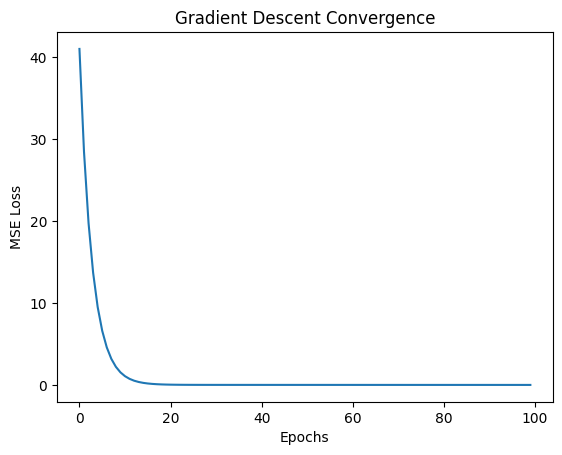

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Dataset
X = np.array([1, 2, 3, 4], dtype=float)
y = np.array([3, 5, 7, 9], dtype=float)

# Initialize Parameters
w = 0.0
b = 0.0

# Hyperparameters
learning_rate = 0.01
epochs = 100
loss_history = []

for epoch in range(epochs):
    # 1. Forward Pass
    y_pred = w * X + b

    # 2. Compute Loss (MSE)
    loss = np.mean((y - y_pred) ** 2)
    loss_history.append(loss)

    # 3. Compute Gradients
    dw = (-2/len(X)) * np.sum(X * (y - y_pred))
    db = (-2/len(X)) * np.sum(y - y_pred)

    # 4. Update Parameters
    w = w - learning_rate * dw
    b = b - learning_rate * db

print(f"Learned Weight: {w:.4f}, Learned Bias: {b:.4f}")

# Plotting Loss Convergence
plt.plot(loss_history)
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Gradient Descent Convergence")
plt.show()


---

## 10. 🚀 Modern Optimization Algorithms

To address the problems faced by standard Gradient Descent, advanced optimizers have been developed:

| Optimizer | Key Mechanism | Best Use Case |
| :--- | :--- | :--- |
| **Momentum** | Adds a fraction of the previous update to the current one or Accumulates past gradients to smooth updates and escape local minima. Like a snowball rolling downhill, it builds speed and easily pushes through flat saddle points.| Escaping local minima, reducing oscillation. |
| **RMSprop** | Adapts the learning rate by dividing the gradient by a running average of its recent magnitude, preventing oscillations in ravines. | Recurrent Neural Networks (RNNs). |
| **Adam (Adaptive Moment Estimation)** | Combines Momentum + RMSprop. | **Default optimizer** for most Deep Learning tasks. |
| **AdamW** | Adam with decoupled weight (L2 regularization) from the gradient update. It is the go-to optimizer for LLMs and Transformers because it generalizes much better than standard Adam. | Transformers, LLMs (BERT, GPT). |

### Practical Tuning Tips
* **Learning Rate Scheduling**: Start with a higher learning rate to escape local minima, then gradually decay it (e.g., Cosine Annealing or Step Decay) to settle perfectly into the global minimum.

* **Gradient Clipping**: If gradients explode, "clip" them at a maximum threshold to maintain stability.

* **Early Stopping**: Monitor the validation loss. If training loss decreases but validation loss increases, you are overfitting. Stop training immediately.

```mermaid
flowchart LR
    A[Vanilla GD] --> B[Mini-Batch GD]
    B --> C[Momentum]
    B --> D[AdaGrad]
    D --> E[RMSprop]
    C --> F[Adam]
    E --> F
    F --> G[AdamW]
    
    style F fill:#e1bee7,stroke:#6a1b9a
    style G fill:#f8bbd0,stroke:#ad1457
```


---

## 11. 🧠 The Deep Learning Bridge

### Epoch vs. Iteration vs. Batch Size
These terms confuse almost everyone. Let's clarify with an example:
*   **Dataset:** 1,000 samples
*   **Batch Size:** 100
*   **Iterations:** 10 (1,000 / 100 = 10 updates per epoch)
*   **Epochs:** 20 (We pass through the whole dataset 20 times)
*   **Total Updates:** 200 (10 iterations × 20 epochs)

### Parameters vs. Hyperparameters
| Parameter | Hyperparameter |
| :--- | :--- |
| Learned by the model (Weights/Biases). | Set by the user *before* training. |
| Updated via Gradient Descent. | Tuned via Grid Search / Random Search. |
| *Example:* $w = 0.45, b = 1.2$ | *Example:* Learning Rate = 0.01, Batch Size = 32 |

### The Chain Rule & Backpropagation

**How do gradients flow through a Neural Network?** 

When you stack layers in a neural network, it becomes a nested function: $y = f(g(x))$.To find how a weight deep inside the network affects the final loss, PyTorch uses the **Chain Rule** from calculus:

$$\frac{\partial L}{\partial w} = \frac{\partial L}{\partial y} \times \frac{\partial y}{\partial w}$$

This backward flow of gradients through the computational graph is called **Backpropagation**. This allows frameworks like PyTorch to automatically compute gradients for millions of parameters by chaining local derivatives backward from the loss to the input.

---

## 12. 📝 Interview Cheat Sheet & Debugging

### 🧠 Top Interview Questions
1. **Why do we need Gradient Descent?** 
> Analytical solutions are computationally impossible for deep learning models with millions of parameters and non-convex loss landscapes.
2. **What happens if the learning rate is too high?** 
> The optimizer will overshoot the minimum, causing the loss to oscillate or diverge (explode).
3. **Why is Adam so popular?** 
> It combines the benefits of Momentum (fast convergence) and RMSprop (adaptive learning rates), making it robust and fast.
4. **What is the difference between a local minimum and a global minimum?** 
> A local minimum is the lowest point in a small region, while a global minimum is the absolute lowest point across the entire loss landscape.
5. **What is the difference between a parameter and a hyperparameter?**
> Parameters (weights/biases) are learned by the model from the data. Hyperparameters (learning rate, batch size, epochs) are set by the engineer to control the learning process.
6. **Why do we initialize neural network weights randomly instead of with zeros?**
> If all weights start at zero, all neurons compute the exact same gradients during backpropagation. Random initialization breaks this symmetry, allowing different neurons to learn different features.
7. **How do you verify if your gradient descent implementation is correct?**
> By using **Gradient Checking**: Compare your manually coded analytical gradient against a numerical gradient approximation using a **small epsilon** ($\epsilon$).
8. **What is the difference between SGD and Mini-Batch GD?**
> SGD updates parameters after a single sample (high variance, noisy). Mini-batch computes the gradient over a small chunk of data (e.g., 32 samples), providing a much smoother and computationally efficient trajectory utilizing vectorized hardware (GPUs).

### ⚠️ Debugging Guide (Practical Tips)
| Symptom | Probable Cause | Solution |
| :--- | :--- | :--- |
| **Loss is NaN / Exploding** | Learning rate too high, or exploding gradients. | Reduce LR, use Gradient Clipping, check for bad data. |
| **Loss is not decreasing** | Learning rate too low, or stuck in local minima. | Increase LR, use Momentum/Adam, check for bugs in code. |
| **Loss oscillates wildly** | Learning rate too high, or batch size too small. | Reduce LR, increase Batch Size. |
| **Train Loss low, Test Loss high** | Overfitting. | Add Regularization (L1/L2), Dropout, Early Stopping, or more data. |
| **Train & Test Loss both high** | Underfitting. | Increase model complexity, train longer, add features. |

### 🗺️ Final Optimization Mind Map


```mermaid
mindmap
  root((Optimization<br/>Summary))
    Parameters
      Define model behavior
      Learned from data
      Optimized via loss function
    Loss Functions
      Measure prediction error
      Guide optimization
      Choose based on problem
    Gradient Descent
      Iterative optimization
      Handles large data
      Works with deep models
    Challenges
      Non-convexity
      Ill-conditioning
      Vanishing/Exploding gradients
      Overfitting
      Scalability
    Solutions
      Momentum
      Adaptive learning rates
      Regularization
      Batch normalization
      Gradient clipping```


```mermaid
flowchart TD
    A[Dataset] --> B[Feature Engineering / Scaling]
    B --> C[Initialize Neural Network]
    C --> D[Forward Pass]
    D --> E[Compute Loss & Regularization]
    E --> F[Backpropagation / Chain Rule]
    F --> G[Optimizer: AdamW / SGD]
    G --> H[Update Weights & Biases]
    H --> I{Validation Loss Improving?}
    I -- Yes --> C
    I -- No --> J[Early Stopping Triggered]
    J --> K[Deploy Final Model]
    style J fill:#ffcccc,stroke:#ff0000,stroke-width:2px
```

**Machine Learning** is fundamentally an `optimization problem`.
> A model starts with random parameters, measures its error using a loss function, computes gradients, updates its parameters using Gradient Descent (or a related optimizer), and repeats this process until the loss is minimized.